## Simplification with minimum time delta algorithm  
We test MobilityPandas, MovingPandas and PyMEOS libraries.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from shapely.geometry import Point

from geopandas import GeoDataFrame

import sys
sys.path.append("../..")
import movingpandas as mpd

import warnings
import numpy as np
warnings.simplefilter("ignore")
from datetime import timedelta

import pymeos
from pymeos.mixins.simplify import TSimplifiable
from pymeos import TGeomPointSeq

pymeos.pymeos_initialize()

## Extraction
We use AIS data.

In [2]:
twenty_traj = True # change here

if twenty_traj:
    zip_path = ['data/aisdk-2025-07-11.zip', 'data/aisdk-2025-07-12.zip']
    csv_filename = ['aisdk-2025-07-11.csv', 'aisdk-2025-07-12.csv']
else:
    zip_path = 'data/aisdk-2025-07-11.zip'
    csv_filename = 'aisdk-2025-07-11.csv'

    sizes = {'small': 100000, 'medium': 1000000, 'large': 4000000}
    chosen_size = 'large'  # change here

## Simplification

In [3]:
def simplify_mpd(trajectories_without):
    return mpd.MinTimeDeltaGeneralizer(trajectories_without).generalize(tolerance=timedelta(seconds=10))

In [4]:
def simplify_pymeos(trajectories_with):
    
    return trajectories_with.trajectory.apply(
        lambda x: TSimplifiable.simplify_min_tdelta(x, distance=timedelta(seconds=10))
    )


## Measures

In [ ]:
import mytools as tools
if twenty_traj:
    df = tools.extraction2()
else:
    df = tools.extraction(chosen_size=chosen_size)

tc = tools.construction_TC(df)
simplified_mpd = tools.mem_and_cpu_time(simplify_mpd, arg=tc)

tg = tools.construction_TG(df)
simplified_pymeos = tools.mem_and_cpu_time(simplify_pymeos, arg=tg)

# Performance measures

## Reduction

In [6]:
nb_points = df.shape[0]

kept_points_without = 0
for traj in simplified_mpd.trajectories :
    kept_points_without += traj.size()

kept_points_with = 0
for traj in simplified_pymeos :
    kept_points_with += traj.num_instants()

print("Percentage of points kept : (with mpd, with pymeos)")
print(np.round(kept_points_without*100/nb_points, 2), '%,  ',
      np.round(kept_points_with*100/nb_points, 2), '%,  ')

Percentage of points kept : (with mpd, with pymeos)
50.73 %,   14.81 %,  


## Preservation

### Spatial-temporal distortion

In [7]:
def calc_distortion_mpd():
    distortion_for_each_traj = []

    trajs_original = list(tc.trajectories)
    trajs_simplified = list(simplified_mpd.trajectories)

    for ti, ts in zip(trajs_original, trajs_simplified):
        timestamps = ti.df.index

        delta_t = np.diff(timestamps).astype('timedelta64[s]').astype(float)

        # extracting the positions at a same time for the two trajectories to compare 
        # left rectangles
        p1lefts, p2lefts = [ti.interpolate_position_at(timestamps[0])], [ts.get_position_at(timestamps[0])] # offset of one
        p1rights, p2rights = [], []

        for t in timestamps[1:-1]:

                p1lefts.append(ti.interpolate_position_at(t))
                p2lefts.append(ts.get_position_at(t))

                p1rights.append(ti.interpolate_position_at(t))
                p2rights.append(ts.get_position_at(t))

        p1rights.append(ti.interpolate_position_at(timestamps[-1]))
        p2rights.append(ts.get_position_at(timestamps[-1]))

        # distances between the two trajectories
        dlefts = np.array([p1.distance(p2) for p1, p2 in zip(p1lefts, p2lefts)])
        drights = np.array([p1.distance(p2) for p1, p2 in zip(p1rights, p2rights)])

        # time * trapeze area, ie integration (vectorized)
        total_area = 0.5 * (dlefts + drights) * delta_t  # [m * s]
        distortion_for_each_traj.append(total_area.sum() / 3600)  # [m * h]

    return distortion_for_each_traj


distortion_mpd = calc_distortion_mpd()

In [8]:
distortion_pymeos = np.array([tg.trajectory.values[i].distance(simplified_pymeos.values[i]).integral()
        for i in range(len(tg.trajectory.values))])/(3600*10**6)

In [9]:
print("maximum distortion with mpd: ", round(max(distortion_mpd), 2), 'h*m,  ')
print("average distortion with mpd: ", round(np.mean(distortion_mpd), 2), 'h*m,  ')

print("maximum distortion with pymeos: ", round(max(distortion_pymeos), 2), 'h*m,  ')
print("average distortion with pymeos: ", round(np.mean(distortion_pymeos), 2), 'h*m,  ')

maximum distortion with mpd:  87843.62 h*m,  
average distortion with mpd:  4523.37 h*m,  
maximum distortion with pymeos:  277958.07 h*m,  
average distortion with pymeos:  15299.24 h*m,  


## Total length of the trajectories

In [11]:
list_of_mmsi = [traj.id for traj in tc]

diff_without, diff_with = [], []
for i in range(len(tc.trajectories)):
      # m = list_of_mmsi[i][0] # for MobilityPandas 
      m = list_of_mmsi[i] # for MovingPandas # TODO correct this difference
      lo = round(tc.trajectories[i].get_length(), 2)
      lwithout = round(simplified_mpd.trajectories[i].get_length(), 2)
      lwith2 = round(simplified_pymeos[m].length(), 2)

      diff_without.append(abs(lo-lwithout))
      diff_with.append(abs(lo-lwith2))

print(f"Maximum length difference with mpd: {round(max(diff_without), 2)} m,   with pymeos: {round(max(diff_with), 2)} m")
print(f"Average length difference with mpd: {round(np.mean(diff_without), 2)} m,   with pymeos: {round(np.mean(diff_with), 2)} m")

Maximum length difference with mpd: 1681743.02 m,   with pymeos: 21826949.59 m
Average length difference with mpd: 84211.15 m,   with pymeos: 1091528.26 m


## Let see

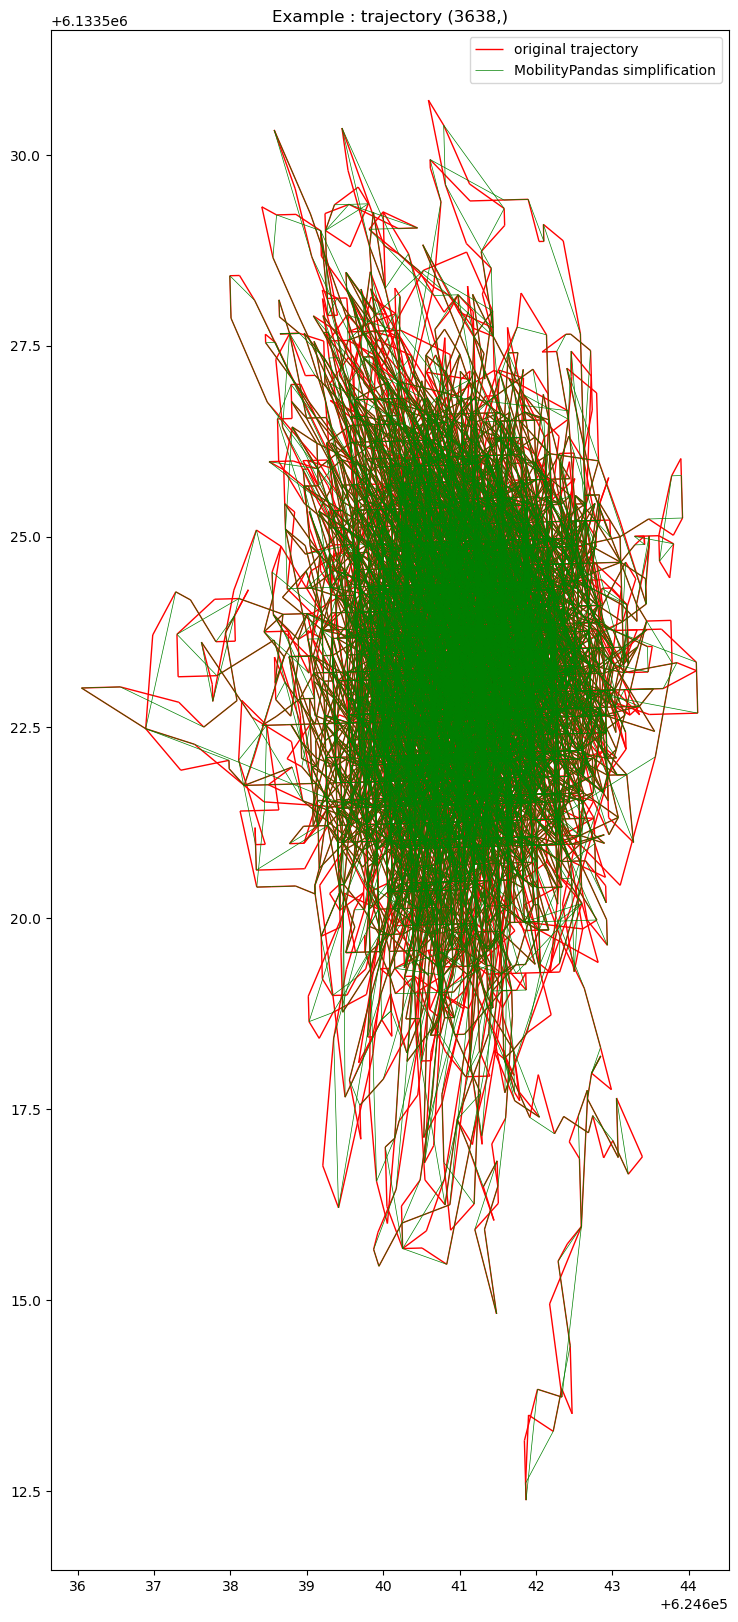

In [ ]:
# Plot one trajectory

n=0
m = [traj.id for traj in tc][n] # the corresponding MMSI

fig, ax = plt.subplots(figsize=(20, 20))
tc.trajectories[n].plot(color='red', label='original trajectory', linewidth=1, ax=ax)
simplified_mpd.trajectories[n].plot(color='green', label='MobilityPandas simplification', ax=ax, linewidth=0.5)

plt.title("Example : trajectory {0}".format(m))
plt.legend()
plt.show()

# pymeos.pymeos_finalize()